## 查找pipeline的官方任务字典

In [6]:
from transformers.pipelines import SUPPORTED_TASKS

In [7]:
#SUPPORTED_TASKS是个字典
#而.item方法是字典的一个方法
                #>>>python中字典的常见方法
                #   >>>value = d[key]通过键值对取值
                #   >>>d.keys()
                #   >>>d.values()
                #   >>>d.items()
for k,v in SUPPORTED_TASKS.items():
    print(k,v,"\n")


audio-classification {'impl': <class 'transformers.pipelines.audio_classification.AudioClassificationPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForAudioClassification'>,), 'default': {'model': ('superb/wav2vec2-base-superb-ks', '372e048')}, 'type': 'audio'} 

automatic-speech-recognition {'impl': <class 'transformers.pipelines.automatic_speech_recognition.AutomaticSpeechRecognitionPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForCTC'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTDT'>, <class 'transformers.models.auto.modeling_auto.AutoModelForSpeechSeq2Seq'>), 'default': {'model': ('facebook/wav2vec2-base-960h', '22aad52')}, 'type': 'multimodal'} 

text-to-audio {'impl': <class 'transformers.pipelines.text_to_audio.TextToAudioPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForTextToWaveform'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTextToSpectrogram'>), 'default':

## pipeline的初始化1.直接使用任务与模型

In [ ]:
from transformers import pipeline
pipe1 = pipeline("text-classification",model = "uer/roberta-base-finetuned-chinanews-chinese")
pipe1("今天天气真好")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'mainland China politics', 'score': 0.8777869939804077}]

## pipeline的初始化2.预先加载模型与分词器（分词器需要提前初始化好）

In [ ]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer
model = AutoModelForSequenceClassification.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
pipe2 = pipeline("text-classification",model = model,tokenizer = tokenizer,device = 0)
pipe2("今天天气真好")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'positive (stars 4 and 5)', 'score': 0.7110825181007385}]

In [6]:
pipe2.model.device
#可以更改使用的设备
pipe3 = pipeline("text-classification",model = model,tokenizer = tokenizer,device = "cpu")
pipe3("你好")

[{'label': 'positive (stars 4 and 5)', 'score': 0.8375502824783325}]

In [7]:
pipe3.model.device

device(type='cpu')

## 测算使用cpu与gpu的速度

In [19]:
#gpu测速
import torch
import time
times = []
for i in range(100):
    torch.cuda.synchronize()
    start = time.time()
    pipe2("我觉得不太行！")
    torch.cuda.synchronize()
    end = time.time()
    times.append(end - start)
print(sum(times) / 100)

0.006969366073608398


In [17]:
#cpu测速
import torch
import time
times = []
for i in range(100):
    torch.cuda.synchronize()
    start = time.time()
    pipe3("我觉得不太行！")
    torch.cuda.synchronize()
    end = time.time()
    times.append(end - start)
print(sum(times) / 100)

0.033449163436889646


In [29]:
uerqa_pipe = pipeline("document-question-answering", model="impira/layoutlm-document-qa",device = 0)

Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

## 查看pipeline的使用参数

In [35]:
uerqa_pipe

DocumentQuestionAnsweringPipeline: {'model': 'LayoutLMForQuestionAnswering', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [ ]:
from transformers import DocumentQuestionAnsweringPipeline
DocumentQuestionAnsweringPipeline
#可以直接查看原文档然后从示例中可以看到简单的使用，或者可以直接在_call_()方法中看到一些其他的参数

## 目标检测

In [36]:
checkpoint = "google/owlvit-base-patch32"
detector = pipeline(model=checkpoint, task="zero-shot-object-detection")

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

d:\anaconda3\envs\transformers\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--google--owlvit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  613MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

In [38]:
import requests
#获取网页数据（GET 请求）：比如下载一个网页的 HTML 源代码，或者请求一个接口返回 JSON 数据。
#提交数据（POST 请求）：比如模拟登录网站、提交表单信息。
#下载图片/文件：通过 URL 把网络上的图片保存到本地
from PIL import Image
url = "https://unsplash.com/photos/oj0zeY2Ltk4/download?ixid=MnwxMjA3fDB8MXxzZWFyY2h8MTR8fHBpY25pY3xlbnwwfHx8fDE2Nzc0OTE1NDk&force=true&w=640"
img = Image.open(requests.get(url=url,stream=True).raw)
ans = detector(img,candidate_labels=["hat","book","sunglasses"])
ans


[{'score': 0.2592525780200958,
  'label': 'sunglasses',
  'box': {'xmin': 349, 'ymin': 228, 'xmax': 430, 'ymax': 265}},
 {'score': 0.18528485298156738,
  'label': 'book',
  'box': {'xmin': 270, 'ymin': 284, 'xmax': 502, 'ymax': 427}},
 {'score': 0.11255767196416855,
  'label': 'hat',
  'box': {'xmin': 39, 'ymin': 173, 'xmax': 260, 'ymax': 363}}]

## 展示图片

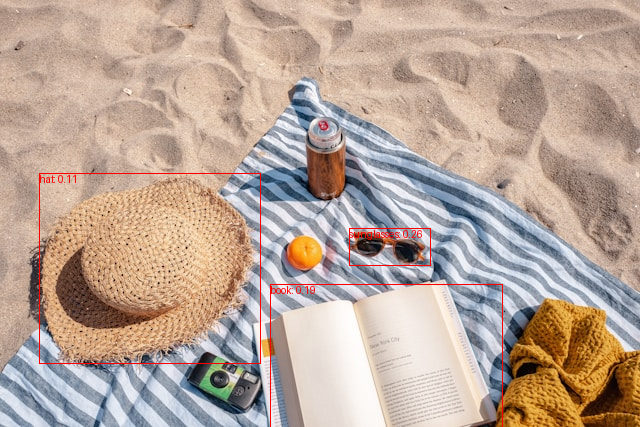

In [39]:
from PIL import ImageDraw

draw = ImageDraw.Draw(img)

for prediction in ans:
    box = prediction["box"]
    label = prediction["label"]
    score = prediction["score"]
    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{label}: {round(score,2)}", fill="red")

img
